## Arrays and Vectorized

### 1. 기본 특징:
1. N차원 배열 만들어줌
2. 시간복잡도 생각 안하고 O(1)로 배열 접근 가능
3. 선형대수 잘 모름 일단 좋음
4. Numpy를 C, C++ 또는 FORTRAN이랑 연결하기 좋음

### 1.1. 속도
numpy는 기본 파이썬보다 약 10~100배 더 빠른 속도를 보여줌

In [74]:
import numpy as np

my_arr = np.arange(1_000_000) # 언더바는 가독성을 위한 요소일 뿐 코드에 직접적인 영향은 없음
# vector<int> my_arr(100000, i); 비슷함. 0 ~ 999,999 의 정수를 가진 배열을 만듦.
my_list = list(range(1_000_000))
%timeit my_arr2 = my_arr * 2
%timeit my_list2 = [x * 2 for x in my_list]
# %timeit 은 벤치마크 도구임 실행 시간을 통계적으로 재는 매직 커맨드임
# [x * 2 for x in my_list] 는 리스트 컴프리헨션이다.  [표현식 for 항목 in iterable if 조건] 도 가능하다
my_list3 = [x * 2 for x in my_list if x % 10 == 0]
print(my_list3[:10])

2.63 ms ± 55.8 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
60.3 ms ± 1.89 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
[0, 20, 40, 60, 80, 100, 120, 140, 160, 180]


### 2. 배열

In [75]:
import numpy as np

data = np.array([[1, 2, 3], [1.5, 0, -3]])
print(data)
# 줄바꿈이 자동으로 들어가서 2차원 배열이 잘 표현됨

data = data * 10
print(data)

data = data + data
print(data)

data.shape
# 2행 3열의 배열
data.dtype # datatype


[[ 1.   2.   3. ]
 [ 1.5  0.  -3. ]]
[[ 10.  20.  30.]
 [ 15.   0. -30.]]
[[ 20.  40.  60.]
 [ 30.   0. -60.]]


dtype('float64')

In [76]:
# 스칼라 요소 간의 연산..? 무튼 수학적 연산에 도움을 줌
data1 = [1, 2, 3, 4]
data2 = [[1, 2, 3,], [10, 9, 8]]
data3 = [[1, 2, 3, 4], ['t', 'e', 's', 't']]


my_arr1 = np.array(data1)
my_arr2 = np.array(data2)
my_arr3 = np.array(data3)

# print(my_arr1)
# print(my_arr2)
# print(my_arr3)

# print(my_arr1.ndim) # N dimension, N 차원
# print(my_arr1.shape)
# print(my_arr2.dtype)
# print(my_arr2.shape)

print(f"{my_arr1.ndim}차원 배열\n데이터 타입:{my_arr1.dtype}\n")
print(f"{my_arr2.ndim}차원 배열\n데이터 타입:{my_arr2.dtype}\n{my_arr2.shape}의 크기를 가졌다.\n")
print(f"{my_arr3.ndim}차원 배열\n데이터 타입:{my_arr3.dtype}\n{my_arr3.shape}의 크기를 가졌다.\n")

1차원 배열
데이터 타입:int64

2차원 배열
데이터 타입:int64
(2, 3)의 크기를 가졌다.

2차원 배열
데이터 타입:<U21
(2, 4)의 크기를 가졌다.



In [184]:
my_arr1 = np.zeros(10)
# vector<int> my_arr(10, 0); 과 비슷함. 10개의 요소를 가진 배열을 만들고 모든 요소는 0으로 초기화
print(my_arr1)

my_arr2 = np.zeros((3, 6))
print(my_arr2) # 3행 6열의 배열을 만들고 모든 요소는 0으로 초기화

my_arr3 = np.ones((2, 2, 2))
print(my_arr3) # 2행 2열 2면의 배열을 만들고 모든 요소는 1로 초기화

my_arr4 = np.empty((2, 3))
print(my_arr4) # 2행 3열의 배열을 만들지만 쓰레기 값을 가지고 있음


[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[[0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]]
[[[1. 1.]
  [1. 1.]]

 [[1. 1.]
  [1. 1.]]]
[[4.9e-324 9.9e-324 1.5e-323]
 [2.0e-323 2.5e-323 3.0e-323]]


In [78]:
print(np.arange(15))
print(list(range(0, 15)))



[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]


#### Array
입력 데이터(리스트, 튜플, 배열 또는 기타 시퀀스)를 데이터 유형을 추론하거나, 지정하여 N차 배열로 변환함. 입력 데이터를 복사함. array(시퀀스)
#### Asarray
입력값을 N차 배열로 변환하되, 입력값이 이미 N차 배열이면 새로 안 만듦. 불필요한 복사하지 않고 그대로 쓴다. asarray(시퀀스)
#### Arange
range랑 비슷한데 return 값이 리스트가 아니고 N차 배열 형태로 반환함. arange(입력값)
#### Full, Full_like
주어진 형태와 데이터 타입을 가진 배열 생성 후 입력받은 값으로 가득 채움 full(형태, 입력값)
#### Eye, identify
대각선에 1, 나머지는 모두 0인 N*N 크기의 정사각형 행렬
#### Zeros, zeros_like | Ones, ones_like

In [90]:
data = [[1,2,3], [4,5,6]]
a = np.array(data)
b = np.ones_like(a)
c = np.ones(a.shape)
print(b)
print(c)
d = np.full(a.shape, 5);
print(d)
e = np.eye(3)
print(e)
f = np.identity(3)
print(f)

[[1 1 1]
 [1 1 1]]
[[1. 1. 1.]
 [1. 1. 1.]]
[[5 5 5]
 [5 5 5]]
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


### 3. N차원 배열의 데이터 유형
#### Astype()
.astype() 은 N차원 배열의 데이터를 입력받은 데이터 유형으로 변경해줌.
1.25, -9.6, 42 이라는 dtype=str 값이 들어오고 이를 int 형식으로 바꾸려면
dtype=str 을 float16 으로 변경하고 그 후에 int를 바꿔야함. (그러지 않음 ValueError를 일으킴)



64 배정밀
32 단정밀
16 반정밀

In [152]:
arr1 = np.array([1, 2, 3], dtype=np.float64)
arr2 = np.array([1, 2, 3], dtype=np.int32)
arr3 = np.array([1, 2, 3], dtype=np.uint8)

print(arr1.dtype)
print(arr2.dtype)
print(arr3.dtype)

arr = np.array([3.7, -1.2, -2.6, 0.5, 12.9, 10.1])
print(arr)
arr = arr.astype(np.int32)
print(arr)
print("ㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡ")
numeric_strings = np.array(["1.25", "-9.6", "42"], dtype=str)
print(numeric_strings)
numeric_strings = numeric_strings.astype(np.float16)
print(numeric_strings)
numeric_strings = numeric_strings.astype(np.int16)
print(numeric_strings)

int_array = np.arange(10) # 0 ~ 9 까지 배열 만듦
print(int_array)
calibers = np.array([.22, .270, .357, .380, .44, .50], dtype=np.float64)
# float64 의 배열을 만듦
print(calibers)
calibers = calibers.astype(np.int32) # float64를 int32로 변환
int_array = int_array.astype(calibers.dtype) # int를 calibers의 데이터 타입으로 변환
print(int_array.dtype)

# 약식코드 사용
all_zero_array = np.zeros(10, dtype="u4") # u4 = int32, uint32
print(all_zero_array)
all_one_array = np.ones(5, dtype=np.uint32)
print(all_one_array)

float64
int32
uint8
[ 3.7 -1.2 -2.6  0.5 12.9 10.1]
[ 3 -1 -2  0 12 10]
ㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡ
['1.25' '-9.6' '42']
[ 1.25 -9.6  42.  ]
[ 1 -9 42]
[0 1 2 3 4 5 6 7 8 9]
[0.22  0.27  0.357 0.38  0.44  0.5  ]
int32
[0 0 0 0 0 0 0 0 0 0]
[1 1 1 1 1]


### 4. Numpy 배열 산술 연산


#### 4.1. 사칙연산

In [157]:
arr = np.array([[1, 2, 3], [4, 5, 6]])
print(arr)
print(arr * arr) # element-wise 곱셈
print(arr - arr) # element-wise 뺄셈
# 계산은 순차적으로 진행됨

[[1 2 3]
 [4 5 6]]
[[ 1  4  9]
 [16 25 36]]
[[0 0 0]
 [0 0 0]]


[^1] element-wise: 요소별 계산

#### 4.2. 비교연산

In [169]:
arr1 = np.array([[0., 4., 1.], [7., 2., 12.]])
arr2 = np.array([[0., 3., 10.], [6., 2., 12.]])
print(arr1)
print(arr2, "\n")

print("arr1 < arr2")
print(arr1 < arr2)
print("arr1 > arr2")
print(arr1 > arr2)
print("arr1 == arr2")
print(arr1 == arr2)

[[ 0.  4.  1.]
 [ 7.  2. 12.]]
[[ 0.  3. 10.]
 [ 6.  2. 12.]] 

arr1 < arr2
[[False False  True]
 [False False False]]
arr1 > arr2
[[False  True False]
 [ True False False]]
arr1 == arr2
[[ True False False]
 [False  True  True]]


### 5. 인덱싱 및 슬라이싱

#### 5.1. 1차원 배열

In [187]:
arr = np.arange(10)
print(arr)

print(arr[2])
print(arr[:3])
print(arr[5:9])
print(arr[3:])

# 얕은 copy
arr_sliced = arr[6:10]
print(arr_sliced)

arr_sliced[0] = 12345
print(arr_sliced, "\n", arr)

everythingCOPY = arr[:]
print(everythingCOPY)

print("ㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡ")

# 깊은 copy
arr_sliced = np.copy(arr[6:10])
print(arr_sliced)
arr_sliced[0] = 999

print(arr_sliced, "\n", arr)

[0 1 2 3 4 5 6 7 8 9]
2
[0 1 2]
[5 6 7 8]
[3 4 5 6 7 8 9]
[6 7 8 9]
[12345     7     8     9] 
 [    0     1     2     3     4     5 12345     7     8     9]
[    0     1     2     3     4     5 12345     7     8     9]
ㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡ
[12345     7     8     9]
[999   7   8   9] 
 [    0     1     2     3     4     5 12345     7     8     9]


#### 5.2. 2차원 배열

In [195]:
arr = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
print(f"[0]: {arr[0]}\n[1]: {arr[1]}\n[2]: {arr[2]}")

print(f"\n[0][1]: {arr[0][1]}") # [1, 2, 3] 의 2가 출력됨
print(f"[2][1]: {arr[2][1]}") # [7, 8, 9] 의 8이 출력됨

[0]: [1 2 3]
[1]: [4 5 6]
[2]: [7 8 9]

[0][1]: 2
[2][1]: 8


### 5.3. 3차원 배열

In [215]:
arr3d = np.array([[[1, 2, 3], [4, 5, 6]], [[7, 8, 9], [10, 11, 12]]])
print(f"[0]: {arr3d[0]}\n[1]: {arr3d[1]}")
print(f"3차원 배열의 크기: {arr3d.shape}\n")

arr3d = np.array([[[1, 2, 3], [4, 5, 6]], [[7, 8, 9], [10, 11, 12]]])
print(f"[0][0][0]: {arr3d[0][0][0]}\n[0][0][1]: {arr3d[0][0][1]}")
print(f"[0][1][0]: {arr3d[0][1][0]}\n[0][1][1]: {arr3d[0][1][1]}\n")

print("[0]번째 2차원 배열 전체 참조")
arr3d[0] = 10
print(arr3d, "\n")

print("[0][0]번째 1차원 배열 전체 참조")
arr3d[0][0] = 100
print(arr3d, "\n")

[0]: [[1 2 3]
 [4 5 6]]
[1]: [[ 7  8  9]
 [10 11 12]]
3차원 배열의 크기: (2, 2, 3)

[0][0][0]: 1
[0][0][1]: 2
[0][1][0]: 4
[0][1][1]: 5

[0]번째 2차원 배열 전체 참조
[[[10 10 10]
  [10 10 10]]

 [[ 7  8  9]
  [10 11 12]]] 

[0][0]번째 1차원 배열 전체 참조
[[[100 100 100]
  [ 10  10  10]]

 [[  7   8   9]
  [ 10  11  12]]] 



#### 5.3.1. 슬라이스를 사용한 인덱싱

In [257]:
arr2d = np.array([[x + 1 for x in range(3)] for i in range(3)])
print(f"기본 2D Array\n{arr2d}\n")
print("0 ~ 1 행 출력함.")
print(arr2d[:2]) # 0 ~ 1 행 출력함./

print("0 ~ 1행, 1 ~ 2열 출력함.")
arr = np.array(arr2d[:2, 1:])
print(arr, "\n")

print("두 번째 행의 첫 번째 두 열을 가져오는 것이 가능함")
lower_dim_slice = arr2d[1, :2]
print(lower_dim_slice, lower_dim_slice.shape) # 1차원 배열이 출력됨
print(arr2d[:3, 0]) # 2차원 배열의 [0 ~ 2]행의 [0]번째 열을 가져옴
print(arr2d[:, :1]) # 모든 행의 1번째 열

기본 2D Array
[[1 2 3]
 [1 2 3]
 [1 2 3]]

0 ~ 1 행 출력함.
[[1 2 3]
 [1 2 3]]
0 ~ 1행, 1 ~ 2열 출력함.
[[2 3]
 [2 3]] 

두 번째 행의 첫 번째 두 열을 가져오는 것이 가능함
[1 2] (2,)
[1 1 1]
[[1]
 [1]
 [1]]


#### 5.3.2. 불리언 인덱싱

and 와 or은 작동하지 않음. 대신 & 혹은 |을 사용해야한다.

In [289]:
names = np.array(["Bob", "Joe", "Will", 'Bob', 'Will', 'Joe', 'Joe'], dtype="<U4")
data = np.array([[4, 7], [0, 2], [-5, 6], [0, 0], [1, 2], [-12, -4], [3, 4]])

print("names 배열과 data 배열")
print(names)
print(data)
print("ㅡ" * 30)

print(names == "Bob")
print(data[names == "Bob", 1:]) # 이름 'Bob'인 사람들의 1번째 열 데이터를 가져옴
print(data[names == "Bob"]) # 이름 'Bob'인 사람들의 0 ~ 1번째 열 데이터를 가져옴
print("ㅡ" * 30)
print(names != "Bob")
print(~(names == "Bob")) # 두 코드 동일함
# print(data[~(names == "Bob")]) # 이름 'Bob'이 아닌 사람들의 0 ~ 1번째 열 데이터를 가져옴
# ~(name == "Bob")은 Bob이 아닌 사람들만 참조하는 불리언 배열임
# data[] 에 집어넣음으로써 해당하는 열 데이터를 가져옴

tricker = names == "Bob"
print(data[~tricker])

print("ㅡ" * 30)

mask = (names == "Bob") | (names == "Will") # Bob 이거나 Will 이거나.
print(data[mask]) # 이름이 'Bob'이거나 'Will'인 사람들의 0 ~ 1번째 열 데이터를 가져옴

names 배열과 data 배열
['Bob' 'Joe' 'Will' 'Bob' 'Will' 'Joe' 'Joe']
[[  4   7]
 [  0   2]
 [ -5   6]
 [  0   0]
 [  1   2]
 [-12  -4]
 [  3   4]]
ㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡ
[ True False False  True False False False]
[[7]
 [0]]
[[4 7]
 [0 0]]
ㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡ
[False  True  True False  True  True  True]
[False  True  True False  True  True  True]
[[  0   2]
 [ -5   6]
 [  1   2]
 [-12  -4]
 [  3   4]]
ㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡ
[[ 4  7]
 [-5  6]
 [ 0  0]
 [ 1  2]]


### 6. 고급 인덱싱

In [306]:
arr = np.zeros((8, 4))

for i in range(8):
    arr[i] = i

print(arr)

# arr[[4, 3, 0, 6]] # 4, 3, 0, 6 번째 행을 참조함
# arr[[-3, -5, -7]] # 5, 3, 1 번째 행을 참조함. - 는 뒤에서 순회하는 것.

arr = np.arange(32).reshape((8, 4)) # 8행 4열의 배열에 0 ~ 31 정수를 넣음.

print(arr[[1, 5, 7, 2], [0, 3, 1, 2]])
# 1, 5, 7, 2번째 행의 0, 3, 1, 2번째 열을 참조한다는 뜻.
# (1, 0), (5, 3), (7, 1), (2, 2) 인덱스

arr[[1, 5, 7, 2]][:, [0, 3, 1, 2]]
# 1, 5, 7, 2 행을 먼저 참조함.
# 이후 [ ,  ,  ,  ,  ] 순서대로 0, 3, 1, 2번째 열을 집어넣음
print("ㅡ" * 30)
arr = np.arange(15).reshape((3, 5))
print("전치행렬 변환 전")
print(arr, "\n")
arr = arr.T # 전치행렬
print("전치행렬 변환 후")
print(arr)

print("ㅡ" * 30)

arr = np.array([[0, 1, 0], [1, 2, -2], [6, 3, 2], [-1, 0, -1], [1, 0, 1]])
print("전치행렬과 본 행렬의 곱")
print(np.dot(arr.T, arr))
# print(arr.T @ arr) .dot() 매서드와 동일함. 매우 간편한!

# 이건 잘 모르겠음
arr = arr.swapaxes(0, 1)
print(arr)

[[0. 0. 0. 0.]
 [1. 1. 1. 1.]
 [2. 2. 2. 2.]
 [3. 3. 3. 3.]
 [4. 4. 4. 4.]
 [5. 5. 5. 5.]
 [6. 6. 6. 6.]
 [7. 7. 7. 7.]]
[ 4 23 29 10]
ㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡ
전치행렬 변환 전
[[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]] 

전치행렬 변환 후
[[ 0  5 10]
 [ 1  6 11]
 [ 2  7 12]
 [ 3  8 13]
 [ 4  9 14]]
ㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡ
전치행렬과 본 행렬의 곱
[[39 20 12]
 [20 14  2]
 [12  2 10]]
[[ 0  1  6 -1  1]
 [ 1  2  3  0  0]
 [ 0 -2  2 -1  1]]


### 7. 의사난수 생성
numpy.random 모듈은 다양한 확률 분포에서 표본 값으로 구성된 전체 배열을 효율적으로 생성하는 함수를 제공함.

파이썬 내장 random 보다 numpy.random 이 더 대단하다는 거임

In [311]:
samples = np.random.standard_normal(size=(4, 4))
print(samples)

[[ 1.24194483  2.56157034  0.44944275 -0.6152154 ]
 [ 0.49431007 -0.58205155  1.11574765 -0.94872005]
 [ 1.28259684 -1.7841187   0.88894237 -0.18309024]
 [ 0.01241844 -0.80030631  0.33618533 -1.86658773]]


In [314]:
from random import normalvariate
N = 1_000_000
%timeit samples = [normalvariate(0, 1) for _ in range(N)]
%timeit samples = np.random.standard_normal(N)

624 ms ± 12.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
22.6 ms ± 1.01 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [320]:
rng = np.random.default_rng(seed=12345)

data = rng.standard_normal((2, 3))
print(data)

type(rng)

[[-1.42382504  1.26372846 -0.87066174]
 [-0.25917323 -0.07534331 -0.74088465]]


numpy.random._generator.Generator

**permutation**: 시퀀스의 무작위 순열을 반환하거나, 순열된 범위를 반환합니다.

**shuffle**: 순서를 제자리에서 무작위로 섞습니다(원본 배열을 직접 변경).

**uniform**: 균일(Uniform) 분포에서 표본을 추출합니다(예: [low, high) 또는 기본 [0, 1) 범위).

**integers**: 주어진 낮은 값에서 높은 값까지의 범위에서 무작위 정수를 추출합니다.

**standard_normal**: 평균 0, 표준편차 1인 표준 정규분포에서 표본을 추출합니다.

**binomial**: 이항분포(Binomial)에서 표본을 추출합니다(시행 횟수와 성공 확률 지정).

**normal**: 평균과 표준편차를 지정하는 정규(가우스) 분포에서 표본을 추출합니다.

**beta**: 베타(Beta) 분포에서 표본을 추출합니다(두 모수 α, β 지정).

**chisquare**: 카이제곱(Chi-square) 분포에서 표본을 추출합니다(자유도 지정).

**gamma**: 감마(Gamma) 분포에서 표본을 추출합니다(모수(shape, scale) 지정).

**uniform**: 균일한 [0, 1) 분포에서 표본을 추출합니다. (위의 `uniform` 항목과 겹칠 수 있음 — 사용 문맥에 따라 파라미터가 달라집니다.)

### 8. 범용 함수: 빠른 요소별 배열 함수

In [323]:
arr = np.arange(10)

arr = np.sqrt(arr) # 제곱근
print(arr)

arr = np.exp(arr) # 지수 함수
print(arr)

[0.         1.         1.41421356 1.73205081 2.         2.23606798
 2.44948974 2.64575131 2.82842712 3.        ]
[ 1.          2.71828183  4.11325038  5.65223367  7.3890561   9.35646902
 11.58243519 14.09403011 16.91882868 20.08553692]


ufunc(universal function)은 요소별(element-wise) 연산을 C로 구현한 함수를 뜻함
벡터화 되어 있어 겁나게 빨라부러잉

In [328]:
x = rng.standard_normal(8)
y = rng.standard_normal(8)

result = np.maximum(x, y) # x와 y의 요소별 최대값을 반환해주는 함수
print(result, "\n")

arr = rng.standard_normal(7) * 5
remainder, whole_part = np.modf(arr) # modf()는 소수와 정수를 분리해서 반환.
print(remainder, "\n", whole_part)

[ 0.89060715  1.02300937  0.31238339  1.3017145   0.74787294  0.98087591
 -0.11041869  0.46791853] 

[-0.22276266 -0.97928306 -0.77623808  0.31915437 -0.37585784 -0.26667965
 -0.62170964] 
 [-1. -9. -0.  5. -1. -9. -0.]


In [332]:
arr = rng.standard_normal(7) * 5

out = np.zeros_like(arr) # arr와 같은 크기의 배열, 전부 0

np.add(arr, 1) # arr의 모든 요소에 + 1
np.add(arr, 2, out=out) # arr의 모든 요소에 + 1 한 결과를 out에 저장

print(f"arr와 out의 차이\n{arr}\n{out}")
# arr의 값은 유지되고 out의 값만 바뀌게 됨

arr와 out의 차이
[-5.6148079  -9.87623834 -2.12575025 -5.74536911  8.07569027 -0.7923843
 -1.26436673]
[-3.6148079  -7.87623834 -0.12575025 -3.74536911 10.07569027  1.2076157
  0.73563327] 


**abs, fabs**: 정수, 부동소수점 또는 복소수 값에 대해 요소별 절댓값을 계산합니다.

**sqrt**: 각 요소의 제곱근을 계산합니다(즉, arr ** 0.5).

**square**: 각 요소의 제곱을 계산합니다(즉, arr ** 2).

**exp**: 각 요소에 대해 자연상수 e의 거듭제곱 e**x를 계산합니다.

**log, log10, log2, log1p**: 각각 자연로그(밑 e), 밑 10 로그, 밑 2 로그, 그리고 log(1 + x)를 계산합니다(log1p는 x가 작을 때 수치 안정적).

**sign**: 각 요소의 부호를 계산합니다: 1(양수), 0(영), -1(음수).

**ceil**: 각 요소를 올림하여 그 수보다 크거나 같은 가장 작은 정수를 반환합니다.

**floor**: 각 요소를 내림하여 그 수보다 작거나 같은 가장 큰 정수를 반환합니다.

**rint**: 각 요소를 가장 가까운 정수로 반올림하여 소수 부분을 제거한 값을 반환합니다(반올림 방식은 짝수로의 반올림 등 구현 세부는 NumPy 규칙 따름).

**modf**: 배열의 소수 부분과 정수 부분을 각각 별도의 배열로 반환합니다(첫 반환값 = 소수 부분, 둘째 = 정수 부분).

**isnan**: 각 값이 NaN인지 여부를 나타내는 부울 배열을 반환합니다.

**isfinite, isinf**: 각각 각 요소가 유한한지(유한: 비-Inf, 비-NaN) 또는 무한인지(±Inf)를 나타내는 부울 배열을 반환합니다.

**cos, cosh, sin, sinh, tan, tanh**: 일반 삼각함수(코사인, 사인, 탄젠트) 및 그에 대응하는 쌍곡선 삼각함수들을 요소별로 계산합니다.

**arccos, arccosh, arcsin, arcsinh, arctan, arctanh**: 역삼각함수(아크 코사인 등)를 요소별로 계산합니다.

**logical_not**: 요소별 논리 부정(not)을 계산하여 부울 배열을 반환합니다(예: not x, ~arr과 동등한 용도).

**add**: 두 배열(또는 배열과 스칼라)의 대응 요소를 더합니다.

**subtract**: 첫 번째 배열에서 두 번째 배열의 대응 요소를 뺍니다.

**multiply**: 두 배열의 대응 요소를 곱합니다.

**divide, floor_divide**: divide는 나눗셈(실수 나눗셈), floor_divide는 나눗셈 후 내림(몫만 취함)을 수행합니다.

**power**: 첫 번째 배열의 각 요소를 두 번째 배열에 지정된 거듭제곱으로 올립니다(요소별 거듭제곱).

**maximum, fmax**: 요소별 최대값을 반환합니다. `fmax`는 NaN을 무시하여 비 NaN 값을 반환하는 차이가 있습니다(한 쪽이 NaN이면 다른 쪽을 선택).

**minimum, fmin**: 요소별 최소값을 반환합니다. `fmin`은 NaN을 무시하는 동작을 합니다.

**mod**: 요소별 나머지(나눗셈의 나머지)를 계산합니다.

**copysign**: 첫 번째 인수의 값은 유지하되, 두 번째 인수의 부호를 첫 번째 인수에 복사하여 반환합니다(절댓값은 첫 번째의 것, 부호는 두 번째의 것).

**greater, greater_equal, less, less_equal, equal, not_equal**: 요소별 비교 연산을 수행하여 부울 배열을 반환합니다(>, >=, <, <=, ==, !=와 동일한 동작).

**logical_and**: 요소별 논리 AND 연산을 수행합니다(부울 배열에서 & 연산과 유사).

**logical_or**: 요소별 논리 OR 연산을 수행합니다(부울 배열에서 | 연산과 유사).

**logical_xor**: 요소별 논리 XOR 연산을 수행합니다(부울 배열에서 ^ 연산과 유사).

### 8. 배열을 이용한 배열 지향 프로그래밍
반복문을 사용해야 하는 다양한 데이터 처리 작업을 간결하게 할 수 있음.
위와 같은 방식을 **벡터화** 라고 부른다.
벡터화된 배열 연산은 순수 Python 보다 개빠름 ㄷㄷ

In [338]:
points = np.arange(-5, 5, 0.01) # -5 ~ 5 까지 0.01 간격으로 배열을 만듦

xs, ys = np.meshgrid(points, points) # 2차원 격자 좌표를 만듦

z = np.sqrt(xs ** 2 + ys ** 2) # xs와 ys의 요소별 제곱의 합의 제곱근을 계산함. z는 xs와 ys의 격자 좌표에서 원점으로부터의 거리를 나타냄

[[7.07106781 7.06400028 7.05693985 ... 7.04988652 7.05693985 7.06400028]
 [7.06400028 7.05692568 7.04985815 ... 7.04279774 7.04985815 7.05692568]
 [7.05693985 7.04985815 7.04278354 ... 7.03571603 7.04278354 7.04985815]
 ...
 [7.04988652 7.04279774 7.03571603 ... 7.0286414  7.03571603 7.04279774]
 [7.05693985 7.04985815 7.04278354 ... 7.03571603 7.04278354 7.04985815]
 [7.06400028 7.05692568 7.04985815 ... 7.04279774 7.04985815 7.05692568]]


#### 8.1 matplotlib 를 통한 시각화

<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
C:\Users\meeso\AppData\Local\Temp\ipykernel_18896\1500188935.py:7: SyntaxWarning: invalid escape sequence '\s'
  plt.title("Image plot of $\sqrt{x^2 + y^2}$ for a grid of values")


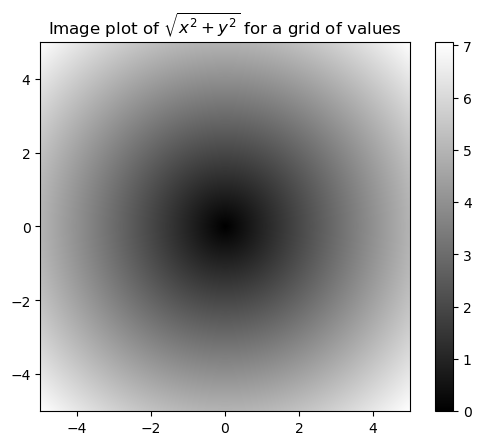

In [343]:
import matplotlib.pyplot as plt

plt.imshow(z, cmap=plt.cm.gray, extent=[-5, 5, -5, 5])

plt.colorbar()

plt.title("Image plot of $\sqrt{x^2 + y^2}$ for a grid of values")

plt.show()


In [344]:
plt.close("all")

### 9. 조건 논리를 배열 연산으로 표현하기
numpy.where() 은 삼항 연산자의 벡터화된 버전 ( = x if condition else y )
condition[i] 가 True 면 x[i]에, False 면 y[i]에 결과 배열을 만듦

In [348]:
xarr = np.array([1.1, 1.2, 1.3, 1.4, 1.5])
yarr = np.array([2.1, 2.2, 2.3, 2.4, 2.5])

cond = np.array([True, False, True, True, False])

result = [(x if c else y) for x, y, c in zip(xarr, yarr, cond)]
# zip()을 x, y, c를 통해 순회하며 c의 조건에 따라 x 혹은 y 한 뒤 리스트 화 함
result

# 1.1 2.2 1.3 1.4 2.5 가 출력되는데
# T   F   T   T   F   이므로 저렇게 나온다

[np.float64(1.1),
 np.float64(2.2),
 np.float64(1.3),
 np.float64(1.4),
 np.float64(2.5)]

위 방식은 배열 크기가 클 수록 속도가 느리다는 것과 다차원 배열은 사용할 수 없다는 것이 문제

In [349]:
result = np.where(cond, xarr, yarr) # 조건, 배열1, 배열2

result

array([1.1, 2.2, 1.3, 1.4, 2.5])

성능, 메모리 측면에선 np.where()이 더 빠르고 효율적임 (벡터화된 C연산)

In [358]:
arr = rng.standard_normal((4, 4))

conditionArr = np.array(arr > 0)

result1 =np.where(conditionArr, arr, -2)
# 음수는 모두 -2로 바꿔버림

result2 = np.where(arr > 0, 2, -2)
# arr의 요소가 0보다 크면 2, 아니면 -2로 바꿔버림

print(result1, "\n", result2)

[[-2.          0.38050908  0.75539067 -2.        ]
 [ 2.15031011 -2.         -2.         -2.        ]
 [ 0.87796618  0.22446741 -2.          0.2262628 ]
 [ 0.68618251  1.21500461  0.21605944 -2.        ]] 
 [[-2  2  2 -2]
 [ 2 -2 -2 -2]
 [ 2  2 -2  2]
 [ 2  2  2 -2]]


### 10. 수학 및 통계 방법론

In [362]:
arr = rng.standard_normal((5, 4))

arr.mean() # 평균값
np.mean(arr) # np.mean() 함수도 동일한 결과를 반환함
arr.sum() # 합계
np.sum(arr) # np.sum() 함수도 동일한 결과를 반환함

arr.mean(axis=1) # 행별 평균값
arr.sum(axis=0) # 열별 합계

array([-1.36809331, -0.73276986,  0.79616511,  2.33469785])

axis 가 1이면 행, 0이면 열

In [368]:
arr = np.arange(8)
print(arr)
arr.cumsum() # 누적합 | 어떻게 함수가 컴 숨 ㄷㄷ


[0 1 2 3 4 5 6 7]


array([ 0,  1,  3,  6, 10, 15, 21, 28])

In [372]:
arr = np.array([[0, 1, 2,], [3, 4, 5], [6, 7, 8]])
print(arr)

axis0arr = arr.cumsum(axis = 0)
print(axis0arr) # 열 누적합

axis1arr = arr.cumsum(axis = 1)
print(axis1arr) # 행 누적합

[[0 1 2]
 [3 4 5]
 [6 7 8]]
[[ 0  1  2]
 [ 3  5  7]
 [ 9 12 15]]
[[ 0  1  3]
 [ 3  7 12]
 [ 6 13 21]]


**sum**: 배열 전체 또는 지정한 축(axis)을 따라 모든 요소의 합을 계산합니다. 길이가 0인 배열의 합은 0입니다.

**mean**: 산술 평균을 계산합니다. 빈 배열에 대해 호출하면 경고와 함께 NaN을 반환할 수 있습니다(입력에 NaN이 포함되면 결과도 NaN).

**std, var**: 각각 표준편차(std)와 분산(var)을 계산합니다. 기본적으로 모집단 기준(ddof=0)으로 계산되며, ddof 인수를 통해 자유도 조정이 가능합니다.

**min, max**: 배열의 최소값(min)과 최대값(max)을 반환합니다(지정한 축을 따라 계산 가능).

**argmin, argmax**: 최소값/최대값을 갖는 원소의 인덱스(위치)를 반환합니다(다차원 배열의 경우 flatten된 인덱스 또는 axis 지정 가능).

**cumsum**: 누적합(cumulative sum)을 계산하여 같은 모양의 배열을 반환합니다. 예: [a, b, c] → [a, a+b, a+b+c]. axis를 지정하면 그 축을 따라 누적합을 계산합니다.

**cumprod**: 누적곱(cumulative product)을 계산하여 같은 모양의 배열을 반환합니다. 예: [a, b, c] → [a, a*b, a*b*c]. axis 인수로 축을 지정할 수 있습니다.

### 11. 불리언 배열을 위한 메서드

In [376]:
arr = rng.standard_normal(100)
(arr > 0).sum()
(arr <= 0).sum()

np.int64(45)

In [379]:
bools = np.array([False, False, True, False])

bools.any() # 하나라도 참인가?

bools.all() # 전부 참인가?

np.False_

In [384]:
arr = rng.standard_normal(6)

print(arr)

arr.sort()
print(arr)

[ 0.79780604 -0.37812935  1.58223187  1.26565747 -0.02972581 -2.63975939]
[-2.63975939 -0.37812935 -0.02972581  0.79780604  1.26565747  1.58223187]


In [389]:
arr = rng.standard_normal((5, 3))
print(arr)

arr.sort(axis=0)
print(arr)
arr.sort(axis=1)
print(arr)

[[ 1.2414271   0.11071174  1.09518667]
 [-0.19669954  0.40445788 -0.40899651]
 [-2.54134859 -0.70903455 -0.26158445]
 [ 0.16263188  0.00800948 -0.1207063 ]
 [ 0.95423778  0.63158305 -0.39150714]]
[[-2.54134859 -0.70903455 -0.40899651]
 [-0.19669954  0.00800948 -0.39150714]
 [ 0.16263188  0.11071174 -0.26158445]
 [ 0.95423778  0.40445788 -0.1207063 ]
 [ 1.2414271   0.63158305  1.09518667]]
[[-2.54134859 -0.70903455 -0.40899651]
 [-0.39150714 -0.19669954  0.00800948]
 [-0.26158445  0.11071174  0.16263188]
 [-0.1207063   0.40445788  0.95423778]
 [ 0.63158305  1.09518667  1.2414271 ]]


In [390]:
arr2 = np.array([5, -10, 7, 1, 0, -3])
sorted_arr2 = np.sort(arr2)

sorted_arr2

array([-10,  -3,   0,   1,   5,   7])

### 12. 고유 및 기타 집합 논리

In [392]:
names = np.array(["Bob", "Joe", "Will", 'Bob', 'Will', 'Joe', 'Joe'], dtype="<U4")
np.unique(names)

ints = np.array([3, 3, 3, 2, 2, 1, 1, 1, 4])
np.unique(ints)

array([1, 2, 3, 4])

데이터가 많을 수록 Numpy가 더 빠르고 Python 리스트 타입이 아닌, Numpy 배열 타입을 반환함

In [406]:
values1 = np.array([6, 0, 0, 3, 2, 5, 6])

np.isin(values1, [2, 3, 6]) # values의 요소가 [2, 3, 6]에 있는지 여부를 불리언 배열로 반환함
#np.in1d(values1, [2, 3, 6]) # np.isin()과 동일한 결과를 반환함. 1차원 배열에 대해서만 사용 가능함



array([ True, False, False,  True,  True, False,  True])

**unique(x)**: x의 정렬된 고유 요소를 반환합니다.

**intersect1d(x, y)**: x와 y의 정렬된 공통 요소(교집합)를 반환합니다.

**union1d(x, y)**: x와 y의 정렬된 합집합 요소를 반환합니다.

**in1d(x, y)**: x 배열의 각 요소가 y에 포함되어 있는지 여부를 나타내는 부울 배열을 반환합니다.

**setdiff1d(x, y)**: x에는 속하지만 y에는 속하지 않는 요소들(집합 차이)을 정렬하여 반환합니다.

**setxor1d(x, y)**: 두 배열의 대칭 차이(양쪽 중 한 쪽에만 있는 요소들)를 정렬하여 반환합니다.


### 13. 배열을 이용한 파일 입력 및 출력

In [412]:
arr = np.arange(10)
np.save("some_array", arr) # 파일경로가 .npy로 끝나지 않으면 자동으로 .npy가 붙음

fp = np.load("some_array.npy")
np.savez("array_archive.npz", a=arr, b=arr) # 여러 배열을 압축된 형태로 저장할 수 있음

# 데이터 압축률이 좋으면(?) 아래처럼 할 수 있음
np.savez_compressed("array_archive_compressed.npz", a=arr, b=arr)

### 14. 선형대수

In [415]:
x = np.array([[1., 2., 3.], [4., 5., 6.]])
y = np.array([[6., 23.], [-1, 7], [8, 9]])

np.dot(x, y) # x와 y의 행렬 곱을 계산함. x의 열 수와 y의 행 수가 일치해야 함.
# x.dot(y) 와 같음

x @ np.ones(3)


array([ 6., 15.])

In [466]:
from numpy.linalg import inv, qr

x = rng.standard_normal((5, 5))

mat = x.T @ x # x의 전치행렬과 x의 행렬 곱을 계산함. 양수값이 나와야 함

inv(mat) # inv() 함수는 역행렬을 계산함. 정방행렬에 대해서만 사용 가능함. 역행렬이 존재하지 않는 경우에는 LinAlgError 예외가 발생하다.

mat @ inv(mat)

array([[ 1.00000000e+00, -3.62709327e-16,  4.19812369e-16,
         5.38709489e-19,  1.37073406e-17],
       [-3.57833159e-17,  1.00000000e+00, -6.95496638e-17,
         1.34045515e-16, -4.86142319e-16],
       [-6.79291093e-17, -1.42264170e-16,  1.00000000e+00,
         3.77490626e-17,  9.08133176e-17],
       [-2.31748323e-17, -2.33305342e-16,  1.89953734e-17,
         1.00000000e+00, -4.00128037e-16],
       [ 4.23286295e-17, -2.70847428e-16,  1.88050857e-17,
        -3.61184325e-18,  1.00000000e+00]])

항등행렬이 되지 않는 이유는.. 반올림/조건수 때문에 정확한 정수가 나오지 못함.
'거의 항동' 인 것이지 아주 작은 오차가 나온다


**diag**: 정사각행렬의 대각선(또는 비대각선) 요소를 1차원 배열로 반환하거나, 1차원 배열을 받아 비대각선 요소가 모두 0인 정사각행렬(대각행렬)로 변환합니다. (입력 차원에 따라 동작이 달라집니다.)

**dot**: 두 배열의 점곱(내적) 또는 행렬곱을 수행합니다. 1D 벡터 간에는 내적, 2D 행렬 간에는 행렬곱을 의미합니다.

**trace**: 행렬의 대각선 요소들의 합을 계산합니다(대각합).

**det**: 정사각행렬의 행렬식(determinant)을 계산합니다.

**eig**: 정사각행렬의 고유값(eigenvalues)과 고유벡터(eigenvectors)를 반환합니다. (복소수 결과 가능)

**inv**: 정사각행렬의 역행렬(inverse)을 계산합니다. 행렬이 특이(singular)하면 LinAlgError가 발생합니다.

**pinv**: 행렬의 무어–펜로즈(Moore–Penrose) 유사역행렬(pseudoinverse)을 계산합니다. 특이행렬이나 직사각행렬에 대해 최소제곱 해 등을 구�� 때 유용합니다.

**qr**: QR 분해를 계산하여 직교 행렬 Q와 상삼각 행렬 R을 반환합니다.

**svd**: 특이값 분해(Singular Value Decomposition)를 계산합니다. 보통 U, s, Vh 형태로 반환되어 행렬을 U @ diag(s) @ Vh로 분해합니다.

**solve**: 정방행렬 A에 대해 선형 시스템 Ax = b를 풀어 해 x를 반환합니다(역행렬을 직접 계산하는 것보다 수치적으로 더 안정적).

**lstsq**: 최소제곱법으로 Ax = b의 해를 구합니다. 해(least-squares solution) 뿐만 아니라 잔차(residuals), 행렬의 랭크(rank), 특이값(s)을 함께 반환합니다.

### 15. Random Walks

동일한 확률로 -1 혹은 1을 추가하는 배열 연산 활용

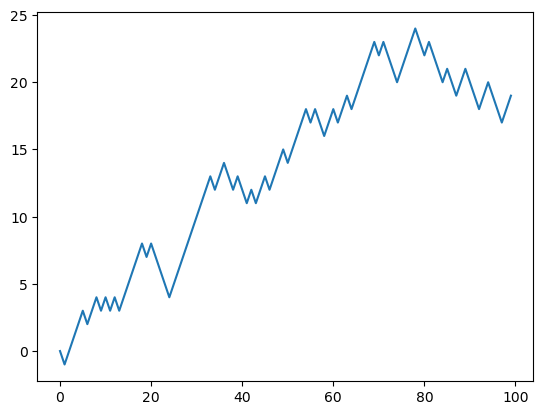

In [474]:
import random

position = 0
walk = [position]
nsteps = 1000
for _ in range(nsteps):
    step = 1 if random.randint(0, 1) else -1
    position += step
    walk.append(position)

plt.plot(walk[:100])

numpy.random 모듈을 사용한 1000번 동전 던지기

np.int64(155)

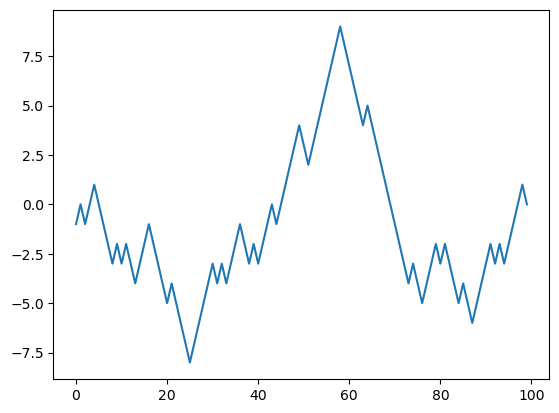

In [487]:
nsteps = 1000
rng = np.random.default_rng(seed=12345)
draws = rng.integers(0, 2, size=nsteps) # 0과 1 사이의 정수를 nsteps 개수만큼 생성함
steps = np.where(draws == 0, 1, -1) # draws의 요소가 0이면 1, 아니면 -1로 바꿔줌
walk = steps.cumsum() # steps의 누적합을 계산함. walk는 steps의 각 요소를 순차적으로 더한 결과를 담은 배열이 됨

walk.min()
walk.max()

plt.plot(walk[:100])

(np.abs(walk) >= 10).argmax() # walk의 절댓값이 10 이상이 되는 최초의 인덱스를 반환함


#### 15.1. 여러 무작위 walk를 동시에 시뮬레이션

In [506]:
nwalks = 5000
nsteps = 1000

draws = rng.integers(0, 2, size=(nwalks, nsteps)) # 0과 1 사이의 정수를 nwalks x nsteps 개수만큼 생성함
steps = np.where(draws == 0, 1, -1) # draws의 요소가 0이면 1, 아니면 -1로 바꿔줌
walks = steps.cumsum(axis = 1) # steps의 누적합을 계산함. walks는 steps의 각 요소를 순차적으로 더한 결과를 담은 배열이 됨

print(walks)
print(walks.min())
print(walks.max())

hits30 = (np.abs(walks) >= 30).any(axis = 1) # walks의 각 행에서 절댓값이 30 이상인 요소가 하나라도 있는지 여부를 불리언 배열로 반환함
hits30.sum() # hits30 배열에서 True인 요소의 개수를 반환함. 즉, walks의 각 행에서 절댓값이 30 이상인 요소가 하나라도 있는 행의 개수를 반환함

crossing_times = (np.abs(walks) >= 30).argmax(axis = 1) # walks의 각 행에서 절댓값이 30 이상이 되는 최초의 인덱스를 반환함. 즉, walks의 각 행에서 절댓값이 30 이상이 되는 최초의 위치를 반환함
print(crossing_times)

crossing_times.mean() # crossing_times 배열의 평균값을 반환함. 즉, walks의 각 행에서 절댓값이 30 이상이 되는 최초의 위치의 평균값을 반환함

[[  1   0   1 ...   2   1   2]
 [ -1  -2  -1 ...   6   7   8]
 [ -1   0   1 ...  56  55  56]
 ...
 [ -1   0   1 ... -48 -49 -48]
 [  1   2   1 ...  12  13  14]
 [  1   2   3 ...  40  41  40]]
-124
111
[  0   0 203 ... 389 709 459]


np.float64(339.3518)